In [1]:
# libraries and settings

import os
import json
import random
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

# reproducibility
RANDOM_STATE = 42

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

try:
    import torch

    torch.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

except ImportError:
    torch = None

RANDOM_STATE

42

In [2]:
# load model data, splits and selected features

MODEL_DATA_FILE = "model_df.pkl"
FEATURE_LIST_FILE = "model_feature_cols.txt"

SPLIT_DIR = Path("splits")
SELECTED_FEATURE_DIR = Path("selected_features")

model_df = pd.read_pickle(MODEL_DATA_FILE)

with open(FEATURE_LIST_FILE, "r", encoding="utf-8") as f:
    model_feature_cols = [line.strip() for line in f.readlines()]

train_indices = pd.read_csv(SPLIT_DIR / "train_indices.csv")["index"].to_numpy()
validation_indices = pd.read_csv(SPLIT_DIR / "validation_indices.csv")["index"].to_numpy()
test_indices = pd.read_csv(SPLIT_DIR / "test_indices.csv")["index"].to_numpy()

with open(SELECTED_FEATURE_DIR / "logistic_selected_feature_cols.txt", "r", encoding="utf-8") as f:
    logistic_selected_cols = [line.strip() for line in f.readlines()]

with open(SELECTED_FEATURE_DIR / "catboost_selected_feature_cols.txt", "r", encoding="utf-8") as f:
    catboost_selected_cols = [line.strip() for line in f.readlines()]

print("model_df shape:", model_df.shape)
print("Total model feature count:", len(model_feature_cols))

print("\nSelected feature counts:")
print("Logistic Regression:", len(logistic_selected_cols))
print("CatBoost:", len(catboost_selected_cols))

print("\nSplit sizes:")
print("Train      :", len(train_indices))
print("Validation :", len(validation_indices))
print("Test       :", len(test_indices))

model_df shape: (359, 793)
Total model feature count: 784

Selected feature counts:
Logistic Regression: 50
CatBoost: 250

Split sizes:
Train      : 251
Validation : 54
Test       : 54


In [3]:
# create train / validation / test datasets

train_df = model_df.iloc[train_indices].copy()
validation_df = model_df.iloc[validation_indices].copy()
test_df = model_df.iloc[test_indices].copy()

y_train = train_df["target"].copy()
y_val = validation_df["target"].copy()
y_test = test_df["target"].copy()

X_train_logistic = train_df[logistic_selected_cols].copy()
X_val_logistic = validation_df[logistic_selected_cols].copy()
X_test_logistic = test_df[logistic_selected_cols].copy()

X_train_catboost = train_df[catboost_selected_cols].copy()
X_val_catboost = validation_df[catboost_selected_cols].copy()
X_test_catboost = test_df[catboost_selected_cols].copy()

print("Logistic Regression shapes:")
print("X_train:", X_train_logistic.shape)
print("X_val  :", X_val_logistic.shape)
print("X_test :", X_test_logistic.shape)

print("\nCatBoost shapes:")
print("X_train:", X_train_catboost.shape)
print("X_val  :", X_val_catboost.shape)
print("X_test :", X_test_catboost.shape)

print("\nTarget distribution - train:")
display(train_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

print("\nTarget distribution - validation:")
display(validation_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

print("\nTarget distribution - test:")
display(test_df["target_label"].value_counts(normalize=True).reindex(["down", "flat", "up"]).round(3))

Logistic Regression shapes:
X_train: (251, 50)
X_val  : (54, 50)
X_test : (54, 50)

CatBoost shapes:
X_train: (251, 250)
X_val  : (54, 250)
X_test : (54, 250)

Target distribution - train:


target_label
down    0.299
flat    0.466
up      0.235
Name: proportion, dtype: float64


Target distribution - validation:


target_label
down    0.259
flat    0.630
up      0.111
Name: proportion, dtype: float64


Target distribution - test:


target_label
down    0.370
flat    0.352
up      0.278
Name: proportion, dtype: float64

In [4]:
# time order and split boundary check

time_split_check = {
    "model_df_time_ordered": model_df["minute"].is_monotonic_increasing,
    "train_time_ordered": train_df["minute"].is_monotonic_increasing,
    "validation_time_ordered": validation_df["minute"].is_monotonic_increasing,
    "test_time_ordered": test_df["minute"].is_monotonic_increasing,
    "train_before_validation": train_df["minute"].max() < validation_df["minute"].min(),
    "validation_before_test": validation_df["minute"].max() < test_df["minute"].min(),
}

display(pd.DataFrame([time_split_check]))

assert time_split_check["model_df_time_ordered"], "model_df zaman sıralı değil."
assert time_split_check["train_time_ordered"], "Train set zaman sıralı değil."
assert time_split_check["validation_time_ordered"], "Validation set zaman sıralı değil."
assert time_split_check["test_time_ordered"], "Test set zaman sıralı değil."
assert time_split_check["train_before_validation"], "Train ve validation zaman sınırı hatalı."
assert time_split_check["validation_before_test"], "Validation ve test zaman sınırı hatalı."

print("Time order and split boundary checks passed.")

print("\nTrain minute range:")
print(train_df["minute"].min(), "→", train_df["minute"].max())

print("\nValidation minute range:")
print(validation_df["minute"].min(), "→", validation_df["minute"].max())

print("\nTest minute range:")
print(test_df["minute"].min(), "→", test_df["minute"].max())

,model_df_time_ordered,train_time_ordered,validation_time_ordered,test_time_ordered,train_before_validation,validation_before_test
0,True,True,True,True,True,True


Time order and split boundary checks passed.

Train minute range:
600 → 850

Validation minute range:
851 → 904

Test minute range:
905 → 958


In [5]:
# create output folders

RESULTS_DIR = Path("results")
MODEL_DIR = Path("models")

METRICS_DIR = RESULTS_DIR / "metrics"
PLOTS_DIR = RESULTS_DIR / "plots"
PREDICTIONS_DIR = RESULTS_DIR / "predictions"

for directory in [
    RESULTS_DIR,
    MODEL_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    PREDICTIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Output folders are ready:")
print("-", RESULTS_DIR)
print("-", MODEL_DIR)
print("-", METRICS_DIR)
print("-", PLOTS_DIR)
print("-", PREDICTIONS_DIR)

Output folders are ready:
- results
- models
- results/metrics
- results/plots
- results/predictions


In [6]:
# helper function for classification metrics

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES = ["down", "flat", "up"]

def calculate_classification_metrics(y_true, y_pred, y_proba=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred),
    }

    for class_id, class_name in zip(CLASS_LABELS, CLASS_NAMES):
        metrics[f"{class_name}_f1"] = f1_score(
            y_true,
            y_pred,
            labels=[class_id],
            average="macro",
            zero_division=0
        )

    if y_proba is not None:
        y_true_bin = label_binarize(y_true, classes=CLASS_LABELS)

        try:
            metrics["roc_auc_macro_ovr"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="macro"
            )
            metrics["roc_auc_weighted_ovr"] = roc_auc_score(
                y_true,
                y_proba,
                multi_class="ovr",
                average="weighted"
            )
        except Exception:
            metrics["roc_auc_macro_ovr"] = np.nan
            metrics["roc_auc_weighted_ovr"] = np.nan

        try:
            metrics["pr_auc_macro"] = average_precision_score(
                y_true_bin,
                y_proba,
                average="macro"
            )
            metrics["pr_auc_weighted"] = average_precision_score(
                y_true_bin,
                y_proba,
                average="weighted"
            )
        except Exception:
            metrics["pr_auc_macro"] = np.nan
            metrics["pr_auc_weighted"] = np.nan

    return metrics

In [7]:
# Optuna imports and settings

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

print("Optuna available:", OPTUNA_AVAILABLE)

if not OPTUNA_AVAILABLE:
    raise ImportError(
        "Optuna is not installed. Please install it with: pip install optuna"
    )

OPTUNA_DIR = Path("optuna_results")
OPTUNA_DIR.mkdir(exist_ok=True)

LOGISTIC_OPTUNA_DB = OPTUNA_DIR / "logistic_regression_study.db"
LOGISTIC_STUDY_NAME = "logistic_regression_final_model"

N_LOGISTIC_TRIALS = 50

print("Logistic Regression Optuna database:", LOGISTIC_OPTUNA_DB)
print("Logistic Regression study name:", LOGISTIC_STUDY_NAME)
print("Number of trials:", N_LOGISTIC_TRIALS)

Optuna available: True
Logistic Regression Optuna database: optuna_results/logistic_regression_study.db
Logistic Regression study name: logistic_regression_final_model
Number of trials: 50


In [8]:
# Logistic Regression Optuna objective

def objective_logistic(trial):

    penalty = trial.suggest_categorical(
        "penalty",
        ["l1", "l2", "elasticnet"]
    )

    C = trial.suggest_float(
        "C",
        1e-3,
        100.0,
        log=True
    )

    params = {
        "C": C,
        "penalty": penalty,
        "solver": "saga",
        "max_iter": 5000,
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
        "n_jobs": 1
    }

    if penalty == "elasticnet":
        params["l1_ratio"] = trial.suggest_float(
            "l1_ratio",
            0.05,
            0.95
        )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(**params))
    ])

    model.fit(X_train_logistic, y_train)

    val_pred = model.predict(X_val_logistic)

    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    return val_macro_f1

In [9]:
# run Logistic Regression Optuna study

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

logistic_study = optuna.create_study(
    study_name=LOGISTIC_STUDY_NAME,
    direction="maximize",
    sampler=sampler,
    storage=f"sqlite:///{LOGISTIC_OPTUNA_DB}",
    load_if_exists=True
)

logistic_study.optimize(
    objective_logistic,
    n_trials=N_LOGISTIC_TRIALS,
    show_progress_bar=True
)

print("Best trial number:", logistic_study.best_trial.number)
print("Best validation macro F1:", round(logistic_study.best_value, 6))

print("\nBest Logistic Regression parameters:")
logistic_best_params = logistic_study.best_params

for key, value in logistic_best_params.items():
    print(f"{key}: {value}")

[I 2026-06-15 06:18:12,831] A new study created in RDB with name: logistic_regression_final_model
Best trial: 0. Best value: 0.420179:   0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-15 06:18:12,888] Trial 0 finished with value: 0.42017943409247754 and parameters: {'penalty': 'l2', 'C': 0.9846738873614568}. Best is trial 0 with value: 0.42017943409247754.


Best trial: 0. Best value: 0.420179:   4%|▍         | 2/50 [00:00<00:13,  3.51it/s]

[I 2026-06-15 06:18:13,410] Trial 1 finished with value: 0.37777777777777777 and parameters: {'penalty': 'l1', 'C': 21.42302175774107}. Best is trial 0 with value: 0.42017943409247754.


Best trial: 0. Best value: 0.420179:  18%|█▊        | 9/50 [00:00<00:03, 13.64it/s]

...

[I 2026-06-15 06:18:17,359] Trial 42 finished with value: 0.3131251275770565 and parameters: {'penalty': 'elasticnet', 'C': 0.3440554809642176, 'l1_ratio': 0.32245017115807884}. Best is trial 22 with value: 0.42367149758454103.
[I 2026-06-15 06:18:17,462] Trial 43 finished with value: 0.4103267973856209 and parameters: {'penalty': 'elasticnet', 'C': 1.688728830082803, 'l1_ratio': 0.5011155347642131}. Best is trial 22 with value: 0.42367149758454103.
[I 2026-06-15 06:18:17,522] Trial 44 finished with value: 0.42367149758454103 and parameters: {'penalty': 'elasticnet', 'C': 0.8431412601081574, 'l1_ratio': 0.22010369698992505}. Best is trial 22 with value: 0.42367149758454103.


Best trial: 22. Best value: 0.423671:  96%|█████████▌| 48/50 [00:04<00:00, 12.99it/s]

[I 2026-06-15 06:18:17,651] Trial 45 finished with value: 0.4103267973856209 and parameters: {'penalty': 'elasticnet', 'C': 4.069633246003561, 'l1_ratio': 0.16951317374533417}. Best is trial 22 with value: 0.42367149758454103.
[I 2026-06-15 06:18:17,747] Trial 46 finished with value: 0.4103267973856209 and parameters: {'penalty': 'elasticnet', 'C': 2.2282227250224604, 'l1_ratio': 0.23335898060823185}. Best is trial 22 with value: 0.42367149758454103.
[I 2026-06-15 06:18:17,796] Trial 47 finished with value: 0.33888888888888885 and parameters: {'penalty': 'elasticnet', 'C': 0.4364075725800966, 'l1_ratio': 0.2748425560434878}. Best is trial 22 with value: 0.42367149758454103.
[I 2026-06-15 06:18:17,830] Trial 48 finished with value: 0.42367149758454103 and parameters: {'penalty': 'l2', 'C': 0.7710732849796293}. Best is trial 22 with value: 0.42367149758454103.


Best trial: 22. Best value: 0.423671: 100%|██████████| 50/50 [00:05<00:00,  9.97it/s]

[I 2026-06-15 06:18:17,854] Trial 49 finished with value: 0.3454616588419405 and parameters: {'penalty': 'l2', 'C': 0.26900355825665445}. Best is trial 22 with value: 0.42367149758454103.
Best trial number: 22
Best validation macro F1: 0.423671

Best Logistic Regression parameters:
penalty: elasticnet
C: 1.0123443082243553
l1_ratio: 0.29836187177108225


In [10]:
# refit Logistic Regression with best Optuna parameters

logistic_final_params = {
    "C": logistic_best_params["C"],
    "penalty": logistic_best_params["penalty"],
    "solver": "saga",
    "max_iter": 5000,
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": 1
}

if logistic_best_params["penalty"] == "elasticnet":
    logistic_final_params["l1_ratio"] = logistic_best_params["l1_ratio"]

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(**logistic_final_params))
])

logistic_model.fit(X_train_logistic, y_train)

logistic_val_pred = logistic_model.predict(X_val_logistic)
logistic_val_proba = logistic_model.predict_proba(X_val_logistic)

logistic_val_metrics = calculate_classification_metrics(
    y_true=y_val,
    y_pred=logistic_val_pred,
    y_proba=logistic_val_proba
)

logistic_val_metrics

{'accuracy': 0.5370370370370371,
 'balanced_accuracy': 0.41409897292250236,
 'macro_f1': 0.42367149758454103,
 'weighted_f1': 0.5459473966720343,
 'precision_macro': 0.4465608465608466,
 'recall_macro': 0.41409897292250236,
 'mcc': 0.11981777132504505,
 'down_f1': 0.5,
 'flat_f1': 0.6376811594202898,
 'up_f1': 0.13333333333333333,
 'roc_auc_macro_ovr': 0.4763830532212885,
 'roc_auc_weighted_ovr': 0.4868055555555556,
 'pr_auc_macro': 0.420155094643547,
 'pr_auc_weighted': 0.5460367636010187}

In [11]:
# Logistic Regression validation report

print("Logistic Regression - Validation Classification Report")
print(
    classification_report(
        y_val,
        logistic_val_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

logistic_val_cm = confusion_matrix(
    y_val,
    logistic_val_pred,
    labels=CLASS_LABELS
)

logistic_val_cm_df = pd.DataFrame(
    logistic_val_cm,
    index=[f"actual_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

display(logistic_val_cm_df)

logistic_val_metrics_df = pd.DataFrame([{
    "model": "Logistic Regression",
    "split": "validation",
    **logistic_val_metrics
}])

display(logistic_val_metrics_df)

Logistic Regression - Validation Classification Report
              precision    recall  f1-score   support

        down       0.60      0.43      0.50        14
        flat       0.63      0.65      0.64        34
          up       0.11      0.17      0.13         6

    accuracy                           0.54        54
   macro avg       0.45      0.41      0.42        54
weighted avg       0.56      0.54      0.55        54



,pred_down,pred_flat,pred_up
actual_down,6,8,0
actual_flat,4,22,8
actual_up,0,5,1


,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,Logistic Regression,validation,0.537037,0.414099,0.423671,0.545947,0.446561,0.414099,0.119818,0.5,0.637681,0.133333,0.476383,0.486806,0.420155,0.546037


In [12]:
# save Logistic Regression validation outputs

logistic_val_metrics_df.to_csv(
    METRICS_DIR / "logistic_regression_validation_metrics.csv",
    index=False
)

logistic_val_cm_df.to_csv(
    METRICS_DIR / "logistic_regression_validation_confusion_matrix.csv",
    index=True
)

logistic_val_predictions_df = pd.DataFrame({
    "split": "validation",
    "true_label": y_val.values,
    "true_label_name": validation_df["target_label"].values,
    "pred_label": logistic_val_pred,
    "pred_label_name": [CLASS_NAMES[int(label)] for label in logistic_val_pred],
    "proba_down": logistic_val_proba[:, 0],
    "proba_flat": logistic_val_proba[:, 1],
    "proba_up": logistic_val_proba[:, 2],
})

logistic_val_predictions_df.to_csv(
    PREDICTIONS_DIR / "logistic_regression_validation_predictions.csv",
    index=False
)

with open(MODEL_DIR / "logistic_regression_model.pkl", "wb") as f:
    pickle.dump(logistic_model, f)

with open(MODEL_DIR / "logistic_regression_best_params.json", "w", encoding="utf-8") as f:
    json.dump(logistic_best_params, f, indent=4)

logistic_trials_df = logistic_study.trials_dataframe()

logistic_trials_df.to_csv(
    METRICS_DIR / "logistic_regression_optuna_trials.csv",
    index=False
)

print("Saved Logistic Regression outputs:")
print("-", METRICS_DIR / "logistic_regression_validation_metrics.csv")
print("-", METRICS_DIR / "logistic_regression_validation_confusion_matrix.csv")
print("-", PREDICTIONS_DIR / "logistic_regression_validation_predictions.csv")
print("-", MODEL_DIR / "logistic_regression_model.pkl")
print("-", MODEL_DIR / "logistic_regression_best_params.json")
print("-", METRICS_DIR / "logistic_regression_optuna_trials.csv")

Saved Logistic Regression outputs:
- results/metrics/logistic_regression_validation_metrics.csv
- results/metrics/logistic_regression_validation_confusion_matrix.csv
- results/predictions/logistic_regression_validation_predictions.csv
- models/logistic_regression_model.pkl
- models/logistic_regression_best_params.json
- results/metrics/logistic_regression_optuna_trials.csv


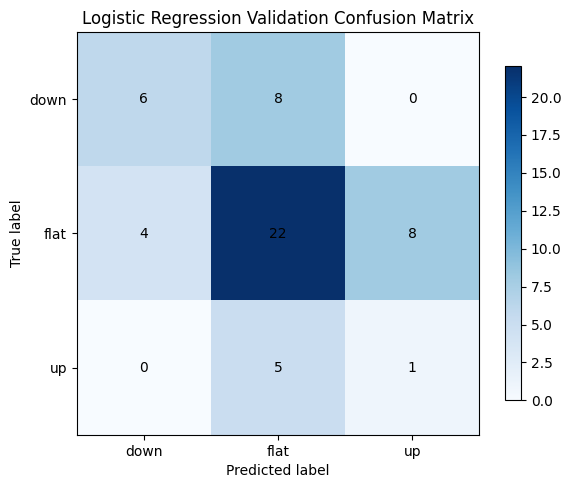

Saved plot: results/plots/logistic_regression_validation_confusion_matrix.png


In [13]:
# plot Logistic Regression validation confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm_plot = ax.imshow(
    logistic_val_cm,
    cmap="Blues"
)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)

ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)

for i in range(logistic_val_cm.shape[0]):
    for j in range(logistic_val_cm.shape[1]):
        ax.text(
            j,
            i,
            logistic_val_cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

ax.set_title("Logistic Regression Validation Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.colorbar(cm_plot, ax=ax, shrink=0.8)

plt.tight_layout()

plot_path = PLOTS_DIR / "logistic_regression_validation_confusion_matrix.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

In [14]:
# CatBoost imports and settings

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False

print("CatBoost available:", CATBOOST_AVAILABLE)

if not CATBOOST_AVAILABLE:
    raise ImportError(
        "CatBoost is not installed. Please install it with: pip install catboost"
    )

CATBOOST_OPTUNA_DB = OPTUNA_DIR / "catboost_final_model_study.db"
CATBOOST_STUDY_NAME = "catboost_final_model"

N_CATBOOST_TRIALS = 50

print("CatBoost Optuna database:", CATBOOST_OPTUNA_DB)
print("CatBoost study name:", CATBOOST_STUDY_NAME)
print("Number of trials:", N_CATBOOST_TRIALS)

CatBoost available: True
CatBoost Optuna database: optuna_results/catboost_final_model_study.db
CatBoost study name: catboost_final_model
Number of trials: 50


In [15]:
# CatBoost Optuna objective

def objective_catboost(trial):

    params = {
        "loss_function": "MultiClass",
        "eval_metric": "MultiClass",
        "iterations": trial.suggest_int("iterations", 200, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "depth": trial.suggest_int("depth", 3, 6),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0, log=True),
        "random_strength": trial.suggest_float("random_strength", 0.1, 5.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 2.0),
        "auto_class_weights": "Balanced",
        "random_seed": RANDOM_STATE,
        "allow_writing_files": False,
        "thread_count": 1,
        "verbose": False
    }

    model = CatBoostClassifier(**params)

    model.fit(
        X_train_catboost,
        y_train,
        eval_set=(X_val_catboost, y_val),
        use_best_model=True,
        early_stopping_rounds=50
    )

    val_pred = model.predict(X_val_catboost).reshape(-1)

    val_macro_f1 = f1_score(
        y_val,
        val_pred,
        average="macro",
        zero_division=0
    )

    return val_macro_f1

In [16]:
# run CatBoost Optuna study

sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

catboost_study = optuna.create_study(
    study_name=CATBOOST_STUDY_NAME,
    direction="maximize",
    sampler=sampler,
    storage=f"sqlite:///{CATBOOST_OPTUNA_DB}",
    load_if_exists=True
)

catboost_study.optimize(
    objective_catboost,
    n_trials=N_CATBOOST_TRIALS,
    show_progress_bar=True
)

print("Best trial number:", catboost_study.best_trial.number)
print("Best validation macro F1:", round(catboost_study.best_value, 6))

print("\nBest CatBoost parameters:")
catboost_best_params = catboost_study.best_params

for key, value in catboost_best_params.items():
    print(f"{key}: {value}")

[I 2026-06-15 06:18:18,202] A new study created in RDB with name: catboost_final_model
Best trial: 0. Best value: 0.376077:   2%|▏         | 1/50 [00:01<01:25,  1.75s/it]

[I 2026-06-15 06:18:19,953] Trial 0 finished with value: 0.37607715573817274 and parameters: {'iterations': 425, 'learning_rate': 0.13125830316209655, 'depth': 5, 'l2_leaf_reg': 3.968793330444372, 'random_strength': 0.18410729205738682, 'bagging_temperature': 0.3119890406724053}. Best is trial 0 with value: 0.37607715573817274.


Best trial: 0. Best value: 0.376077:   4%|▍         | 2/50 [00:06<02:40,  3.35s/it]

[I 2026-06-15 06:18:24,424] Trial 1 finished with value: 0.32106782106782106 and parameters: {'iterations': 234, 'learning_rate': 0.10440040750544663, 'depth': 5, 'l2_leaf_reg': 5.105903209394756, 'random_strength': 0.10838581269344748, 'bagging_temperature': 1.9398197043239886}. Best is trial 0 with value: 0.37607715573817274.


Best trial: 0. Best value: 0.376077:   6%|▌         | 3/50 [00:07<01:43,  2.20s/it]

...

[I 2026-06-15 06:22:20,252] Trial 47 finished with value: 0.4602898550724637 and parameters: {'iterations': 653, 'learning_rate': 0.1118805678010059, 'depth': 5, 'l2_leaf_reg': 7.899062744371409, 'random_strength': 2.427059987373136, 'bagging_temperature': 1.7974874674938468}. Best is trial 8 with value: 0.5384615384615384.


Best trial: 8. Best value: 0.538462:  98%|█████████▊| 49/50 [04:05<00:02,  2.75s/it]

[I 2026-06-15 06:22:23,426] Trial 48 finished with value: 0.38475355054302424 and parameters: {'iterations': 598, 'learning_rate': 0.14215950863272128, 'depth': 6, 'l2_leaf_reg': 8.693785540866068, 'random_strength': 1.2534949577101455, 'bagging_temperature': 1.950849407670486}. Best is trial 8 with value: 0.5384615384615384.


Best trial: 8. Best value: 0.538462: 100%|██████████| 50/50 [04:07<00:00,  4.96s/it]

[I 2026-06-15 06:22:26,067] Trial 49 finished with value: 0.328042328042328 and parameters: {'iterations': 272, 'learning_rate': 0.12941777875044028, 'depth': 5, 'l2_leaf_reg': 6.0012165700852735, 'random_strength': 2.0746023771054696, 'bagging_temperature': 1.6325714491387693}. Best is trial 8 with value: 0.5384615384615384.
Best trial number: 8
Best validation macro F1: 0.538462

Best CatBoost parameters:
iterations: 528
learning_rate: 0.016497027917250065
depth: 6
l2_leaf_reg: 5.958443469672519
random_strength: 3.946212980759093
bagging_temperature: 1.7896547008552977


In [17]:
# refit final CatBoost model with best Optuna parameters

catboost_final_params = {
    "loss_function": "MultiClass",
    "eval_metric": "MultiClass",
    "iterations": catboost_best_params["iterations"],
    "learning_rate": catboost_best_params["learning_rate"],
    "depth": catboost_best_params["depth"],
    "l2_leaf_reg": catboost_best_params["l2_leaf_reg"],
    "random_strength": catboost_best_params["random_strength"],
    "bagging_temperature": catboost_best_params["bagging_temperature"],
    "auto_class_weights": "Balanced",
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "thread_count": 1,
    "verbose": False
}

catboost_model = CatBoostClassifier(**catboost_final_params)

catboost_model.fit(
    X_train_catboost,
    y_train,
    eval_set=(X_val_catboost, y_val),
    use_best_model=True,
    early_stopping_rounds=50
)

catboost_val_pred = catboost_model.predict(X_val_catboost).reshape(-1)
catboost_val_proba = catboost_model.predict_proba(X_val_catboost)

catboost_val_metrics = calculate_classification_metrics(
    y_true=y_val,
    y_pred=catboost_val_pred,
    y_proba=catboost_val_proba
)

catboost_val_metrics

{'accuracy': 0.6666666666666666,
 'balanced_accuracy': 0.5639589169000933,
 'macro_f1': 0.5384615384615384,
 'weighted_f1': 0.620032988454041,
 'precision_macro': 0.5619047619047619,
 'recall_macro': 0.5639589169000933,
 'mcc': 0.3147823023792615,
 'down_f1': 0.21052631578947367,
 'flat_f1': 0.7894736842105263,
 'up_f1': 0.6153846153846154,
 'roc_auc_macro_ovr': 0.6949190787426082,
 'roc_auc_weighted_ovr': 0.6608024691358025,
 'pr_auc_macro': 0.5076722147242313,
 'pr_auc_weighted': 0.5829052830135686}

In [18]:
# CatBoost validation report

print("CatBoost - Validation Classification Report")
print(
    classification_report(
        y_val,
        catboost_val_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

catboost_val_cm = confusion_matrix(
    y_val,
    catboost_val_pred,
    labels=CLASS_LABELS
)

catboost_val_cm_df = pd.DataFrame(
    catboost_val_cm,
    index=[f"actual_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

display(catboost_val_cm_df)

catboost_val_metrics_df = pd.DataFrame([{
    "model": "CatBoost",
    "split": "validation",
    **catboost_val_metrics
}])

display(catboost_val_metrics_df)

CatBoost - Validation Classification Report
              precision    recall  f1-score   support

        down       0.40      0.14      0.21        14
        flat       0.71      0.88      0.79        34
          up       0.57      0.67      0.62         6

    accuracy                           0.67        54
   macro avg       0.56      0.56      0.54        54
weighted avg       0.62      0.67      0.62        54



,pred_down,pred_flat,pred_up
actual_down,2,10,2
actual_flat,3,30,1
actual_up,0,2,4


,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,CatBoost,validation,0.666667,0.563959,0.538462,0.620033,0.561905,0.563959,0.314782,0.210526,0.789474,0.615385,0.694919,0.660802,0.507672,0.582905


In [19]:
# save CatBoost validation outputs

catboost_val_metrics_df.to_csv(
    METRICS_DIR / "catboost_validation_metrics.csv",
    index=False
)

catboost_val_cm_df.to_csv(
    METRICS_DIR / "catboost_validation_confusion_matrix.csv",
    index=True
)

catboost_val_predictions_df = pd.DataFrame({
    "split": "validation",
    "true_label": y_val.values,
    "true_label_name": validation_df["target_label"].values,
    "pred_label": catboost_val_pred,
    "pred_label_name": [CLASS_NAMES[int(label)] for label in catboost_val_pred],
    "proba_down": catboost_val_proba[:, 0],
    "proba_flat": catboost_val_proba[:, 1],
    "proba_up": catboost_val_proba[:, 2],
})

catboost_val_predictions_df.to_csv(
    PREDICTIONS_DIR / "catboost_validation_predictions.csv",
    index=False
)

with open(MODEL_DIR / "catboost_model.pkl", "wb") as f:
    pickle.dump(catboost_model, f)

with open(MODEL_DIR / "catboost_best_params.json", "w", encoding="utf-8") as f:
    json.dump(catboost_best_params, f, indent=4)

catboost_trials_df = catboost_study.trials_dataframe()

catboost_trials_df.to_csv(
    METRICS_DIR / "catboost_optuna_trials.csv",
    index=False
)

print("Saved CatBoost outputs:")
print("-", METRICS_DIR / "catboost_validation_metrics.csv")
print("-", METRICS_DIR / "catboost_validation_confusion_matrix.csv")
print("-", PREDICTIONS_DIR / "catboost_validation_predictions.csv")
print("-", MODEL_DIR / "catboost_model.pkl")
print("-", MODEL_DIR / "catboost_best_params.json")
print("-", METRICS_DIR / "catboost_optuna_trials.csv")

Saved CatBoost outputs:
- results/metrics/catboost_validation_metrics.csv
- results/metrics/catboost_validation_confusion_matrix.csv
- results/predictions/catboost_validation_predictions.csv
- models/catboost_model.pkl
- models/catboost_best_params.json
- results/metrics/catboost_optuna_trials.csv


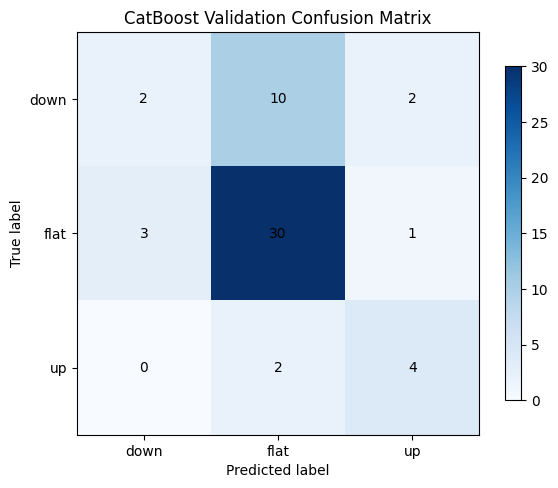

Saved plot: results/plots/catboost_validation_confusion_matrix.png


In [20]:
# plot CatBoost validation confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

cm_plot = ax.imshow(
    catboost_val_cm,
    cmap="Blues"
)

ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)

ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_yticklabels(CLASS_NAMES)

for i in range(catboost_val_cm.shape[0]):
    for j in range(catboost_val_cm.shape[1]):
        ax.text(
            j,
            i,
            catboost_val_cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

ax.set_title("CatBoost Validation Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

plt.colorbar(cm_plot, ax=ax, shrink=0.8)

plt.tight_layout()

plot_path = PLOTS_DIR / "catboost_validation_confusion_matrix.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

In [21]:
# compare validation metrics

validation_comparison_df = pd.concat(
    [
        logistic_val_metrics_df,
        catboost_val_metrics_df
    ],
    ignore_index=True
)

metric_order = [
    "model",
    "split",
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
    "precision_macro",
    "recall_macro",
    "mcc",
    "down_f1",
    "flat_f1",
    "up_f1",
    "roc_auc_macro_ovr",
    "roc_auc_weighted_ovr",
    "pr_auc_macro",
    "pr_auc_weighted"
]

validation_comparison_df = validation_comparison_df[
    [col for col in metric_order if col in validation_comparison_df.columns]
]

display(validation_comparison_df)

validation_comparison_df.to_csv(
    METRICS_DIR / "validation_model_comparison.csv",
    index=False
)

print("Saved validation comparison:")
print("-", METRICS_DIR / "validation_model_comparison.csv")

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,Logistic Regression,validation,0.537037,0.414099,0.423671,0.545947,0.446561,0.414099,0.119818,0.500000,0.637681,0.133333,0.476383,0.486806,0.420155,0.546037
1,CatBoost,validation,0.666667,0.563959,0.538462,0.620033,0.561905,0.563959,0.314782,0.210526,0.789474,0.615385,0.694919,0.660802,0.507672,0.582905


Saved validation comparison:
- results/metrics/validation_model_comparison.csv


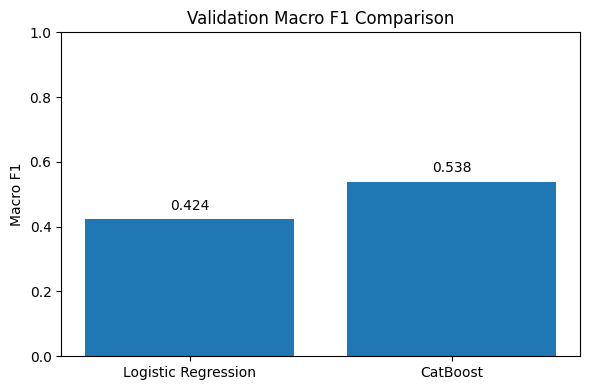

Saved plot: results/plots/validation_macro_f1_comparison.png


In [22]:
# plot validation macro F1 comparison

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    validation_comparison_df["model"],
    validation_comparison_df["macro_f1"]
)

ax.set_title("Validation Macro F1 Comparison")
ax.set_ylabel("Macro F1")
ax.set_ylim(0, 1)

for i, value in enumerate(validation_comparison_df["macro_f1"]):
    ax.text(
        i,
        value + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plot_path = PLOTS_DIR / "validation_macro_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

In [23]:
# final test evaluation

# Logistic Regression test predictions
logistic_test_pred = logistic_model.predict(X_test_logistic)
logistic_test_proba = logistic_model.predict_proba(X_test_logistic)

logistic_test_metrics = calculate_classification_metrics(
    y_true=y_test,
    y_pred=logistic_test_pred,
    y_proba=logistic_test_proba
)

# CatBoost test predictions
catboost_test_pred = catboost_model.predict(X_test_catboost).reshape(-1)
catboost_test_proba = catboost_model.predict_proba(X_test_catboost)

catboost_test_metrics = calculate_classification_metrics(
    y_true=y_test,
    y_pred=catboost_test_pred,
    y_proba=catboost_test_proba
)

test_metrics_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "split": "test",
        **logistic_test_metrics
    },
    {
        "model": "CatBoost",
        "split": "test",
        **catboost_test_metrics
    }
])

test_metrics_df = test_metrics_df[
    [col for col in metric_order if col in test_metrics_df.columns]
]

display(test_metrics_df)

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,Logistic Regression,test,0.407407,0.37924,0.349829,0.371650,0.352203,0.37924,0.087389,0.509804,0.444444,0.095238,0.510596,0.516795,0.382268,0.390929
1,CatBoost,test,0.296296,0.34152,0.216708,0.197684,0.235056,0.34152,0.023072,0.000000,0.230769,0.419355,0.592389,0.590959,0.445183,0.448653


In [24]:
# test classification reports

print("Logistic Regression - Test Classification Report")
print(
    classification_report(
        y_test,
        logistic_test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

print("\nCatBoost - Test Classification Report")
print(
    classification_report(
        y_test,
        catboost_test_pred,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

Logistic Regression - Test Classification Report
              precision    recall  f1-score   support

        down       0.42      0.65      0.51        20
        flat       0.47      0.42      0.44        19
          up       0.17      0.07      0.10        15

    accuracy                           0.41        54
   macro avg       0.35      0.38      0.35        54
weighted avg       0.37      0.41      0.37        54


CatBoost - Test Classification Report
              precision    recall  f1-score   support

        down       0.00      0.00      0.00        20
        flat       0.43      0.16      0.23        19
          up       0.28      0.87      0.42        15

    accuracy                           0.30        54
   macro avg       0.24      0.34      0.22        54
weighted avg       0.23      0.30      0.20        54



In [25]:
# test confusion matrices

logistic_test_cm = confusion_matrix(
    y_test,
    logistic_test_pred,
    labels=CLASS_LABELS
)

catboost_test_cm = confusion_matrix(
    y_test,
    catboost_test_pred,
    labels=CLASS_LABELS
)

logistic_test_cm_df = pd.DataFrame(
    logistic_test_cm,
    index=[f"actual_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

catboost_test_cm_df = pd.DataFrame(
    catboost_test_cm,
    index=[f"actual_{name}" for name in CLASS_NAMES],
    columns=[f"pred_{name}" for name in CLASS_NAMES]
)

print("Logistic Regression - Test Confusion Matrix")
display(logistic_test_cm_df)

print("CatBoost - Test Confusion Matrix")
display(catboost_test_cm_df)

Logistic Regression - Test Confusion Matrix


,pred_down,pred_flat,pred_up
actual_down,13,5,2
actual_flat,8,8,3
actual_up,10,4,1


CatBoost - Test Confusion Matrix


,pred_down,pred_flat,pred_up
actual_down,0,2,18
actual_flat,0,3,16
actual_up,0,2,13


In [26]:
# save test outputs

test_metrics_df.to_csv(
    METRICS_DIR / "test_model_comparison.csv",
    index=False
)

logistic_test_cm_df.to_csv(
    METRICS_DIR / "logistic_regression_test_confusion_matrix.csv",
    index=True
)

catboost_test_cm_df.to_csv(
    METRICS_DIR / "catboost_test_confusion_matrix.csv",
    index=True
)

logistic_test_predictions_df = pd.DataFrame({
    "split": "test",
    "true_label": y_test.values,
    "true_label_name": test_df["target_label"].values,
    "pred_label": logistic_test_pred,
    "pred_label_name": [CLASS_NAMES[int(label)] for label in logistic_test_pred],
    "proba_down": logistic_test_proba[:, 0],
    "proba_flat": logistic_test_proba[:, 1],
    "proba_up": logistic_test_proba[:, 2],
})

catboost_test_predictions_df = pd.DataFrame({
    "split": "test",
    "true_label": y_test.values,
    "true_label_name": test_df["target_label"].values,
    "pred_label": catboost_test_pred,
    "pred_label_name": [CLASS_NAMES[int(label)] for label in catboost_test_pred],
    "proba_down": catboost_test_proba[:, 0],
    "proba_flat": catboost_test_proba[:, 1],
    "proba_up": catboost_test_proba[:, 2],
})

logistic_test_predictions_df.to_csv(
    PREDICTIONS_DIR / "logistic_regression_test_predictions.csv",
    index=False
)

catboost_test_predictions_df.to_csv(
    PREDICTIONS_DIR / "catboost_test_predictions.csv",
    index=False
)

print("Saved test outputs:")
print("-", METRICS_DIR / "test_model_comparison.csv")
print("-", METRICS_DIR / "logistic_regression_test_confusion_matrix.csv")
print("-", METRICS_DIR / "catboost_test_confusion_matrix.csv")
print("-", PREDICTIONS_DIR / "logistic_regression_test_predictions.csv")
print("-", PREDICTIONS_DIR / "catboost_test_predictions.csv")

Saved test outputs:
- results/metrics/test_model_comparison.csv
- results/metrics/logistic_regression_test_confusion_matrix.csv
- results/metrics/catboost_test_confusion_matrix.csv
- results/predictions/logistic_regression_test_predictions.csv
- results/predictions/catboost_test_predictions.csv


In [27]:
# combine validation and test metrics

all_tabular_metrics_df = pd.concat(
    [
        validation_comparison_df,
        test_metrics_df
    ],
    ignore_index=True
)

all_tabular_metrics_df = all_tabular_metrics_df[
    [col for col in metric_order if col in all_tabular_metrics_df.columns]
]

display(all_tabular_metrics_df)

all_tabular_metrics_df.to_csv(
    METRICS_DIR / "tabular_models_validation_test_metrics.csv",
    index=False
)

print("Saved combined validation-test metrics:")
print("-", METRICS_DIR / "tabular_models_validation_test_metrics.csv")

,model,split,accuracy,balanced_accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,mcc,down_f1,flat_f1,up_f1,roc_auc_macro_ovr,roc_auc_weighted_ovr,pr_auc_macro,pr_auc_weighted
0,Logistic Regression,validation,0.537037,0.414099,0.423671,0.545947,0.446561,0.414099,0.119818,0.500000,0.637681,0.133333,0.476383,0.486806,0.420155,0.546037
1,CatBoost,validation,0.666667,0.563959,0.538462,0.620033,0.561905,0.563959,0.314782,0.210526,0.789474,0.615385,0.694919,0.660802,0.507672,0.582905
2,Logistic Regression,test,0.407407,0.379240,0.349829,0.371650,0.352203,0.379240,0.087389,0.509804,0.444444,0.095238,0.510596,0.516795,0.382268,0.390929
3,CatBoost,test,0.296296,0.341520,0.216708,0.197684,0.235056,0.341520,0.023072,0.000000,0.230769,0.419355,0.592389,0.590959,0.445183,0.448653


Saved combined validation-test metrics:
- results/metrics/tabular_models_validation_test_metrics.csv


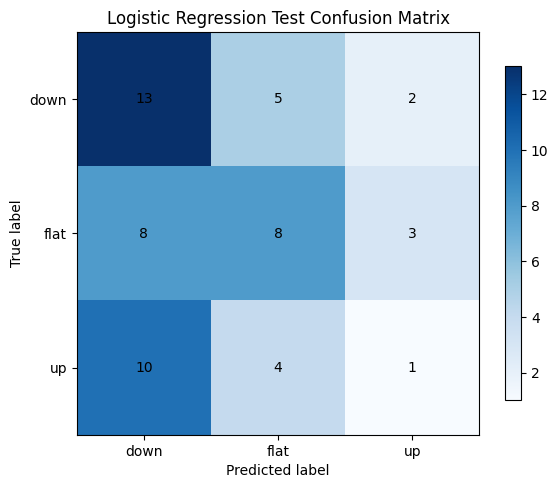

Saved plot: results/plots/logistic_regression_test_confusion_matrix.png


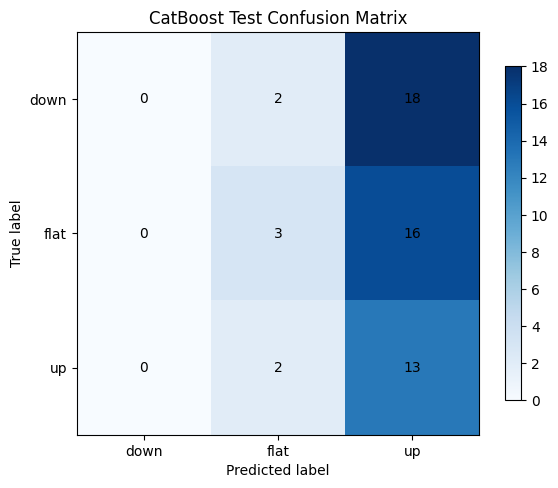

Saved plot: results/plots/catboost_test_confusion_matrix.png


In [28]:
# plot test confusion matrices

def plot_confusion_matrix(cm, title, save_path):
    fig, ax = plt.subplots(figsize=(6, 5))

    cm_plot = ax.imshow(
        cm,
        cmap="Blues"
    )

    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES)

    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_yticklabels(CLASS_NAMES)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="black"
            )

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.colorbar(cm_plot, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", save_path)


plot_confusion_matrix(
    logistic_test_cm,
    "Logistic Regression Test Confusion Matrix",
    PLOTS_DIR / "logistic_regression_test_confusion_matrix.png"
)

plot_confusion_matrix(
    catboost_test_cm,
    "CatBoost Test Confusion Matrix",
    PLOTS_DIR / "catboost_test_confusion_matrix.png"
)

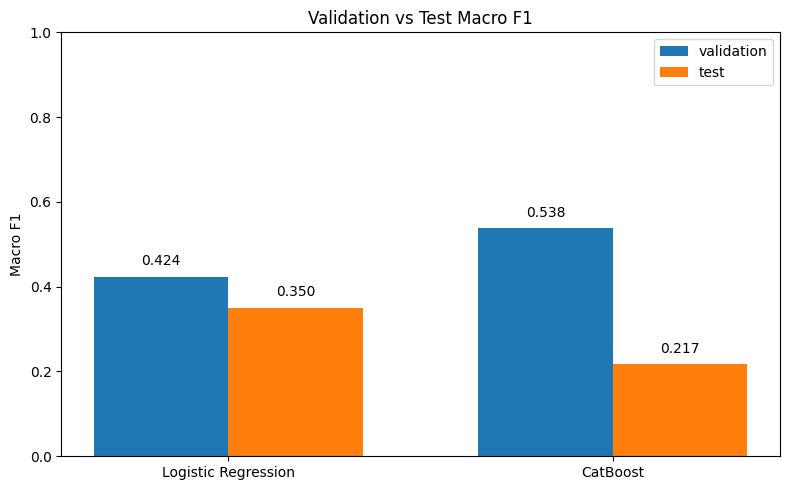

Saved plot: results/plots/validation_test_macro_f1_comparison.png


In [29]:
# plot validation vs test macro F1 comparison

macro_f1_plot_df = all_tabular_metrics_df[
    ["model", "split", "macro_f1"]
].copy()

fig, ax = plt.subplots(figsize=(8, 5))

models = macro_f1_plot_df["model"].unique()
splits = ["validation", "test"]

x = np.arange(len(models))
width = 0.35

for i, split in enumerate(splits):
    values = []

    for model_name in models:
        value = macro_f1_plot_df[
            (macro_f1_plot_df["model"] == model_name) &
            (macro_f1_plot_df["split"] == split)
        ]["macro_f1"].iloc[0]

        values.append(value)

    positions = x + (i - 0.5) * width

    ax.bar(
        positions,
        values,
        width,
        label=split
    )

    for pos, value in zip(positions, values):
        ax.text(
            pos,
            value + 0.02,
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylabel("Macro F1")
ax.set_title("Validation vs Test Macro F1")
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()

plot_path = PLOTS_DIR / "validation_test_macro_f1_comparison.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

plt.show()

print("Saved plot:", plot_path)

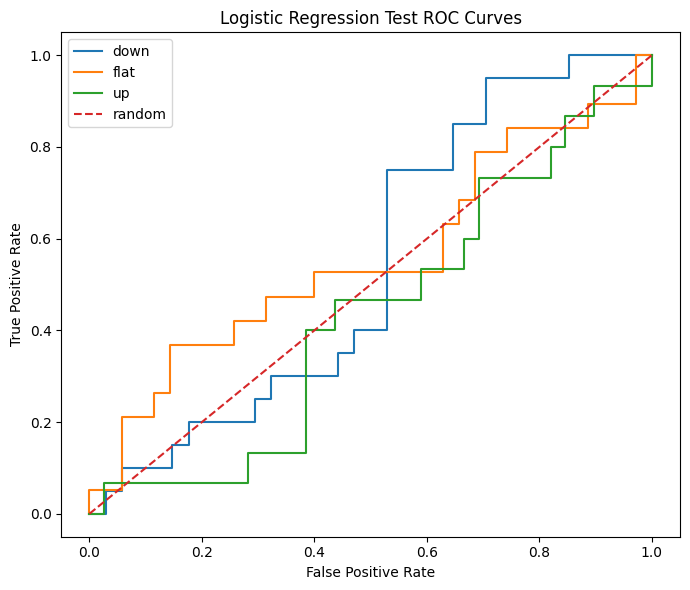

Saved plot: results/plots/logistic_regression_test_roc_curves.png


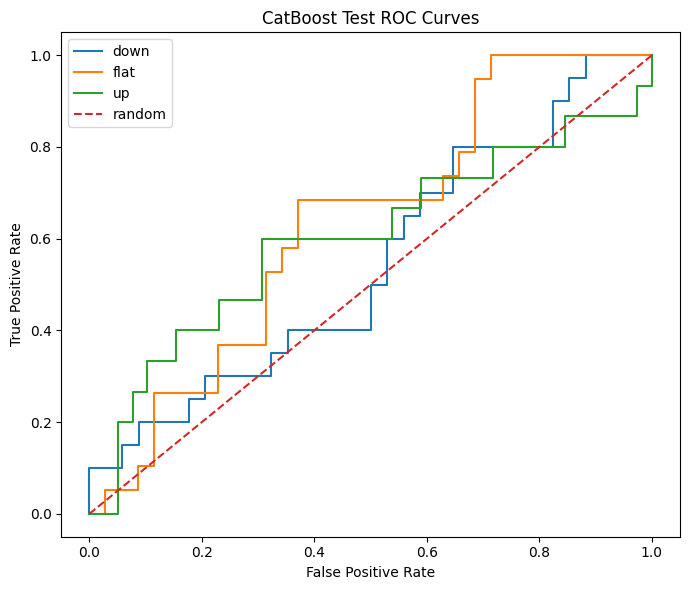

Saved plot: results/plots/catboost_test_roc_curves.png


In [30]:
# plot ROC curves on test set

def plot_multiclass_roc_curves(y_true, y_proba, model_name, save_path):
    y_true_bin = label_binarize(y_true, classes=CLASS_LABELS)

    fig, ax = plt.subplots(figsize=(7, 6))

    for class_index, class_name in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(
            y_true_bin[:, class_index],
            y_proba[:, class_index]
        )

        ax.plot(
            fpr,
            tpr,
            label=f"{class_name}"
        )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="random"
    )

    ax.set_title(f"{model_name} Test ROC Curves")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", save_path)


plot_multiclass_roc_curves(
    y_test,
    logistic_test_proba,
    "Logistic Regression",
    PLOTS_DIR / "logistic_regression_test_roc_curves.png"
)

plot_multiclass_roc_curves(
    y_test,
    catboost_test_proba,
    "CatBoost",
    PLOTS_DIR / "catboost_test_roc_curves.png"
)

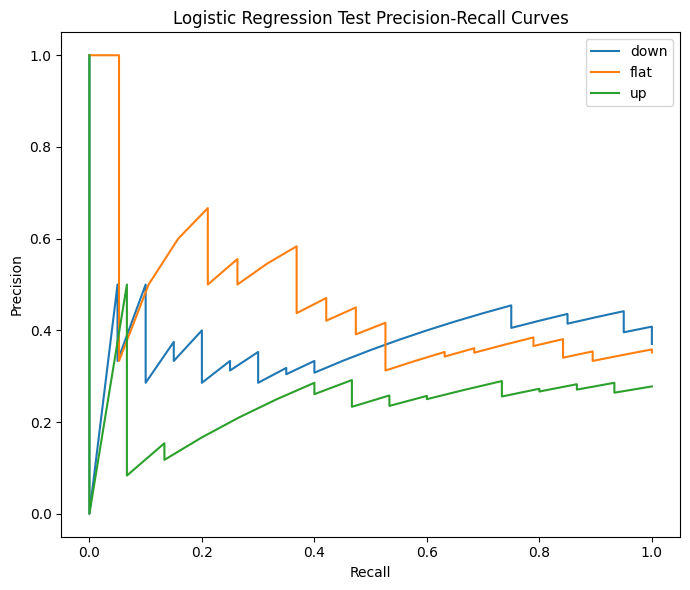

Saved plot: results/plots/logistic_regression_test_pr_curves.png


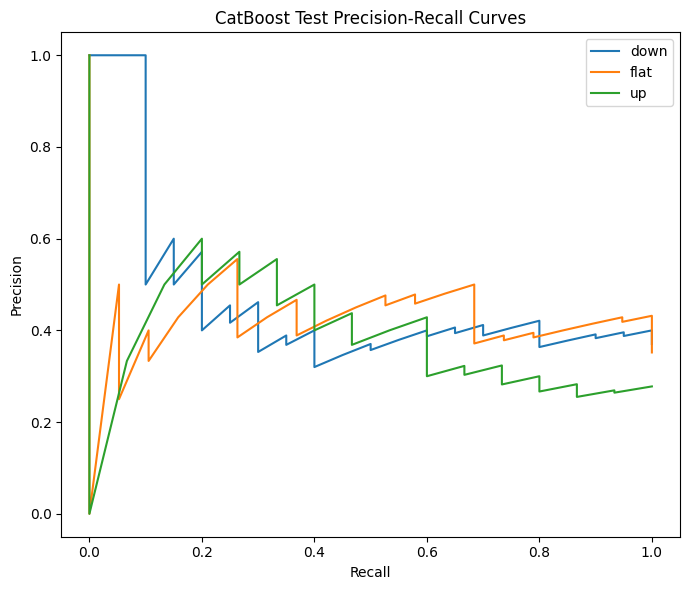

Saved plot: results/plots/catboost_test_pr_curves.png


In [31]:
# plot precision-recall curves on test set

def plot_multiclass_pr_curves(y_true, y_proba, model_name, save_path):
    y_true_bin = label_binarize(y_true, classes=CLASS_LABELS)

    fig, ax = plt.subplots(figsize=(7, 6))

    for class_index, class_name in enumerate(CLASS_NAMES):
        precision, recall, _ = precision_recall_curve(
            y_true_bin[:, class_index],
            y_proba[:, class_index]
        )

        ax.plot(
            recall,
            precision,
            label=f"{class_name}"
        )

    ax.set_title(f"{model_name} Test Precision-Recall Curves")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved plot:", save_path)


plot_multiclass_pr_curves(
    y_test,
    logistic_test_proba,
    "Logistic Regression",
    PLOTS_DIR / "logistic_regression_test_pr_curves.png"
)

plot_multiclass_pr_curves(
    y_test,
    catboost_test_proba,
    "CatBoost",
    PLOTS_DIR / "catboost_test_pr_curves.png"
)

In [32]:
# final saved output check

expected_outputs = [
    # validation metrics
    METRICS_DIR / "logistic_regression_validation_metrics.csv",
    METRICS_DIR / "catboost_validation_metrics.csv",
    METRICS_DIR / "validation_model_comparison.csv",

    # test metrics
    METRICS_DIR / "test_model_comparison.csv",
    METRICS_DIR / "tabular_models_validation_test_metrics.csv",

    # confusion matrices
    METRICS_DIR / "logistic_regression_validation_confusion_matrix.csv",
    METRICS_DIR / "catboost_validation_confusion_matrix.csv",
    METRICS_DIR / "logistic_regression_test_confusion_matrix.csv",
    METRICS_DIR / "catboost_test_confusion_matrix.csv",

    # predictions
    PREDICTIONS_DIR / "logistic_regression_validation_predictions.csv",
    PREDICTIONS_DIR / "catboost_validation_predictions.csv",
    PREDICTIONS_DIR / "logistic_regression_test_predictions.csv",
    PREDICTIONS_DIR / "catboost_test_predictions.csv",

    # models and params
    MODEL_DIR / "logistic_regression_model.pkl",
    MODEL_DIR / "catboost_model.pkl",
    MODEL_DIR / "logistic_regression_best_params.json",
    MODEL_DIR / "catboost_best_params.json",

    # plots
    PLOTS_DIR / "logistic_regression_validation_confusion_matrix.png",
    PLOTS_DIR / "catboost_validation_confusion_matrix.png",
    PLOTS_DIR / "logistic_regression_test_confusion_matrix.png",
    PLOTS_DIR / "catboost_test_confusion_matrix.png",
    PLOTS_DIR / "validation_macro_f1_comparison.png",
    PLOTS_DIR / "validation_test_macro_f1_comparison.png",
    PLOTS_DIR / "logistic_regression_test_roc_curves.png",
    PLOTS_DIR / "catboost_test_roc_curves.png",
    PLOTS_DIR / "logistic_regression_test_pr_curves.png",
    PLOTS_DIR / "catboost_test_pr_curves.png",
]

output_check = []

for file_path in expected_outputs:
    output_check.append({
        "file": str(file_path),
        "exists": file_path.exists()
    })

output_check_df = pd.DataFrame(output_check)

display(output_check_df)

assert output_check_df["exists"].all(), "Some expected output files are missing."

print("All expected tabular model outputs were saved successfully.")

,file,exists
0,results/metrics/logistic_regression_validation...,True
1,results/metrics/catboost_validation_metrics.csv,True
2,results/metrics/validation_model_comparison.csv,True
3,results/metrics/test_model_comparison.csv,True
4,results/metrics/tabular_models_validation_test...,True
5,results/metrics/logistic_regression_validation...,True
6,results/metrics/catboost_validation_confusion_...,True
7,results/metrics/logistic_regression_test_confu...,True
8,results/metrics/catboost_test_confusion_matrix...,True
9,results/predictions/logistic_regression_valida...,True


All expected tabular model outputs were saved successfully.


In [33]:
# # Notebook 04 Summary — Tabular Models

# This notebook trains and evaluates the tabular models for the LOBSTER minute-level price direction prediction task.

# The notebook uses the modeling dataset and fixed time-based train, validation and test splits created in Notebook 02. It also loads the selected feature sets created in Notebook 03.

# Two tabular models are evaluated:

# 1. Logistic Regression  
# 2. CatBoost  

# ## Logistic Regression

# Logistic Regression is trained using the selected 85-feature set from Notebook 03.

# Optuna is used to tune the Logistic Regression hyperparameters using the validation set. The final Logistic Regression model uses Elastic Net regularization.

# The best validation macro F1 obtained by Logistic Regression is approximately:

# ```text
# 0.320